In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from datetime import datetime

# ── 운영체제별 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

In [2]:
df = pd.read_csv("course_final.csv", encoding="utf-8")
df.head()

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
0,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,...,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
1,HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
2,HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
3,HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
4,HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


### 0. 기존 분석의 파생변수들 생성

In [3]:
# sufficient 정의

# 1. 정상 학습 기반 집단 정의
certified_clean = df[
    (df["certified"] == 1) &
    (df["explored"] == 1)
]

# 2. 강의별 nchapters 75% 지점 계산
p75_by_course = (
    certified_clean
    .groupby("course_id")["nchapters"]
    .quantile(0.75)
    .reset_index()
    .rename(columns={"nchapters": "nchapters_p75"})
)

# 3. merge
df = df.merge(p75_by_course, on="course_id", how="left")

# 4. sufficient 생성
df["sufficient"] = (
    (df["nchapters"] >= df["nchapters_p75"]) &
    (df["explored"] == 1)
).astype(int)

In [4]:
df["early_drop"] = (df["duration"] <= 14).astype(int)

df["early_drop"].value_counts()

early_drop
1    321616
0    212377
Name: count, dtype: int64

In [5]:
df["early_drop"].value_counts(normalize=True)

early_drop
1    0.602285
0    0.397715
Name: proportion, dtype: float64

### 1. 일자별 이탈 분석

- 일별 이탈 유저 수를 시각화 했을 때, 보통 온보딩이라고 정의되는 14일까지의 이탈 유저가 확연히 많은 것을 확인할 수 있다.

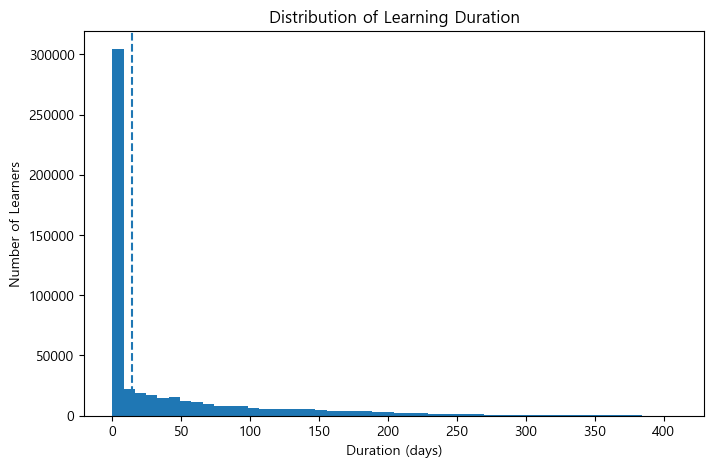

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["duration"].dropna(), bins=50)
plt.axvline(14, linestyle="--")
plt.title("Distribution of Learning Duration")
plt.xlabel("Duration (days)")
plt.ylabel("Number of Learners")
plt.show()

In [22]:
pd.crosstab(df["early_drop"], df["viewed"], normalize="index")

viewed,0,1
early_drop,,
0,0.092251,0.907749
1,0.587782,0.412218


In [23]:
pd.crosstab(df["early_drop"], df["explored"], normalize="index")

explored,0,1
early_drop,,
0,0.829252,0.170748
1,0.995893,0.004107


In [24]:
pd.crosstab(df["early_drop"], df["sufficient"], normalize="index")

sufficient,0,1
early_drop,,
0,0.945375,0.054625
1,0.999164,0.000836


Funnel 단계와의 교차 분포를 확인한 결과,  
early drop 집단은 viewed 비율이 약 41% 수준에 그치며,  
explored와 sufficient 단계로의 전환은 거의 발생하지 않는 것으로 나타났다.

특히 explored 비율이 약 0.4%, sufficient 비율이 0.08% 수준에 불과하다는 점은,  
초기 이탈이 발생한 학습자는 사실상 학습 단계로 진입하지 못한 상태에서  
이탈이 발생한다는 것을 보여준다.

- 일별 이탈률을 좀 더 구체적으로 확인하기 위해, 일별 이탈률을 계산해 시각화하였다.

In [25]:
df_proportion = df.value_counts('duration').reset_index().sort_values('duration')
df_proportion['proportion'] = df_proportion['count'] / len(df)
df_proportion['fail_rate'] = 1 - df_proportion['proportion'].cumsum()

df_proportion['duration'] = df_proportion['duration'] + 1
start_point = pd.DataFrame({'duration':[0], 'fail_rate':[1.0]})
df_plot = pd.concat([start_point, df_proportion]).sort_values('duration').reset_index(drop = True)
df_plot.head(17)

,duration,fail_rate,count,proportion
0,0,1.000000,NaN,NaN
1,1,0.557878,236090.0,0.442122
2,2,0.491342,35530.0,0.066536
3,3,0.477400,7445.0,0.013942
4,4,0.467424,5327.0,0.009976
5,5,0.458978,4510.0,0.008446
6,6,0.451379,4058.0,0.007599
7,7,0.443822,4035.0,0.007556
8,8,0.436378,3975.0,0.007444
9,9,0.429966,3424.0,0.006412


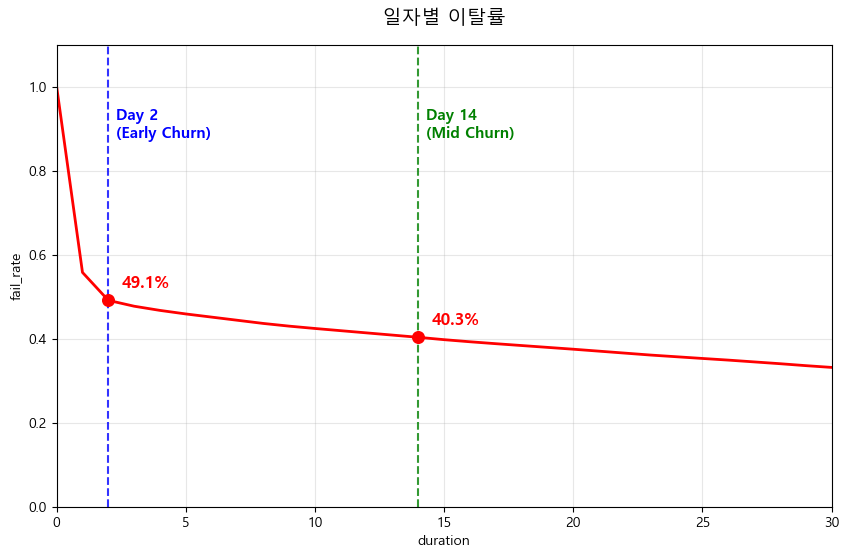

In [26]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='duration', y='fail_rate', color='red', linewidth=2)

# 세로선 긋기
plt.axvline(x=2, color='blue', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axvline(x=14, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

# 상단 레이블 텍스트
plt.text(2.3, 0.95, 'Day 2\n(Early Churn)', color='blue', fontsize=11, fontweight='bold', va='top')
plt.text(14.3, 0.95, 'Day 14\n(Mid Churn)', color='green', fontsize=11, fontweight='bold', va='top')


val_day2 = df_plot.loc[df_plot['duration'] == 2, 'fail_rate'].values[0]
val_day14 = df_plot.loc[df_plot['duration'] == 14, 'fail_rate'].values[0]

# 1. 교차점에 동그란 포인트(점) 찍기 
plt.scatter([2, 14], [val_day2, val_day14], color='red', s=70, zorder=5)

# 2. 수치 텍스트 달아주기 (퍼센트로 변환해서 소수점 1자리까지 표시)
# y좌표에 +0.03을 해서 점 살짝 위에 글씨가 뜨게 만듭니다.
plt.text(2.5, val_day2 + 0.03, f'{val_day2*100:.1f}%', color='red', fontsize=12, fontweight='bold')
plt.text(14.5, val_day14 + 0.03, f'{val_day14*100:.1f}%', color='red', fontsize=12, fontweight='bold')
    

plt.xlim(0, 30)
plt.ylim(0, 1.1) 
plt.title('일자별 이탈률', fontsize=14, pad=15)
plt.grid(True, alpha=0.3)

plt.show()

- 일자별 이탈률 표와 시각화 그래프를 통해, 초기 2일에 전체 50% 이상의 유저가 이탈을 하고 14일에 60% 가량의 유저가 이탈을 진행한다.

- 2일 이내 이탈자는 단순 호기심에 의한 '허수 트래픽'일 가능성이 높다. 비즈니스 관점에서 실질적으로 리텐션(잔존율)을 개선하기 위해서는 **'최소 2주간 강의를 탐색하며 적응을 시도하다 포기한 유저'**를 붙잡는 것이 훨씬 효과적이라 판단했다. 이에 따라 본 분석에서는 '초기 이탈'의 기준을 14일로 정의하고 핵심 타겟 방어 전략을 도출했다.

- 따라서, 14일 이내에 이탈한 유저를 메인으로, 2일 이내 이탈 유저를 보조적인 지표로 활용해 분석을 진행하였다.

### 2. 가입 시기별 초기 이탈률 비교

In [27]:
df["early_drop_14"] = (df["duration"] <= 14).astype(int)
df["early_drop_2"] = (df["duration"] <= 2).astype(int)

df['start_time_DI'] = pd.to_datetime(df['start_time_DI'])
df['cohort_month'] = df['start_time_DI'].dt.to_period('M')

df_cohort_period = df.groupby('cohort_month').agg(
    total_users = ('start_time_DI', 'count'),
    drop_2_count = ('early_drop_2', 'sum'),
    drop_14_count = ('early_drop_14', 'sum')
).reset_index()

df_cohort_period['drop_2_rate'] = df_cohort_period['drop_2_count'] / df_cohort_period['total_users']
df_cohort_period['drop_14_rate'] = df_cohort_period['drop_14_count'] / df_cohort_period['total_users']
df_cohort_period

,cohort_month,total_users,drop_2_count,drop_14_count,drop_2_rate,drop_14_rate
0,2012-07,16261,8926,9044,0.548921,0.556177
1,2012-08,64322,35819,36671,0.556870,0.570116
2,2012-09,51621,25594,28916,0.495806,0.560160
3,2012-10,51649,27917,33752,0.540514,0.653488
4,2012-11,16854,10194,11460,0.604842,0.679957
5,2012-12,33072,16651,17433,0.503477,0.527123
6,2013-01,58255,21608,22567,0.370921,0.387383
7,2013-02,66292,26167,32965,0.394723,0.497270
8,2013-03,58049,29927,38436,0.515547,0.662130
9,2013-04,30531,18330,21235,0.600373,0.695523


In [28]:
print(df['start_time_DI'].max())
print(df['last_event_DI'].max())

2013-09-07 00:00:00
2013-09-07


- 9월의 초기 이탈률이 100%임을 확인해 현재 마지막 가입일과 활동일을 확인했을 때, 2013-09-07로 이 시점이 데이터 집계 시점임을 추측할 수 있다.

- 따라서, 이 일자의 2주 전의 데이터는 초기 이탈을 정확하게 분석할 수 없는 데이터라 판단하고 제거 후 분석을 진행하였다.

In [29]:
cutoff_date = df['start_time_DI'].max() - pd.Timedelta(days=14)

print(f"데이터의 마지막 가입일: {df['start_time_DI'].max()}")
print(f"안전 관찰 기준일 (Cut-off): {cutoff_date}")

df_valid = df[df['start_time_DI'] <= cutoff_date].copy()

print(f"제거 전 원본 데이터 수: {len(df):,}명")
print(f"제거 후 분석용 데이터 수: {len(df_valid):,}명")

데이터의 마지막 가입일: 2013-09-07 00:00:00
안전 관찰 기준일 (Cut-off): 2013-08-24 00:00:00
제거 전 원본 데이터 수: 533,993명
제거 후 분석용 데이터 수: 526,046명


In [31]:
df_cohort_period = df_valid.groupby('cohort_month').agg(
    total_users = ('start_time_DI', 'count'),
    drop_2_count = ('early_drop_2', 'sum'),
    drop_14_count = ('early_drop_14', 'sum')
).reset_index()

df_cohort_period['drop_2_rate'] = df_cohort_period['drop_2_count'] / df_cohort_period['total_users']
df_cohort_period['drop_14_rate'] = df_cohort_period['drop_14_count'] / df_cohort_period['total_users']
df_cohort_period

,cohort_month,total_users,drop_2_count,drop_14_count,drop_2_rate,drop_14_rate
0,2012-07,16261,8926,9044,0.548921,0.556177
1,2012-08,64322,35819,36671,0.556870,0.570116
2,2012-09,51621,25594,28916,0.495806,0.560160
3,2012-10,51649,27917,33752,0.540514,0.653488
4,2012-11,16854,10194,11460,0.604842,0.679957
5,2012-12,33072,16651,17433,0.503477,0.527123
6,2013-01,58255,21608,22567,0.370921,0.387383
7,2013-02,66292,26167,32965,0.394723,0.497270
8,2013-03,58049,29927,38436,0.515547,0.662130
9,2013-04,30531,18330,21235,0.600373,0.695523


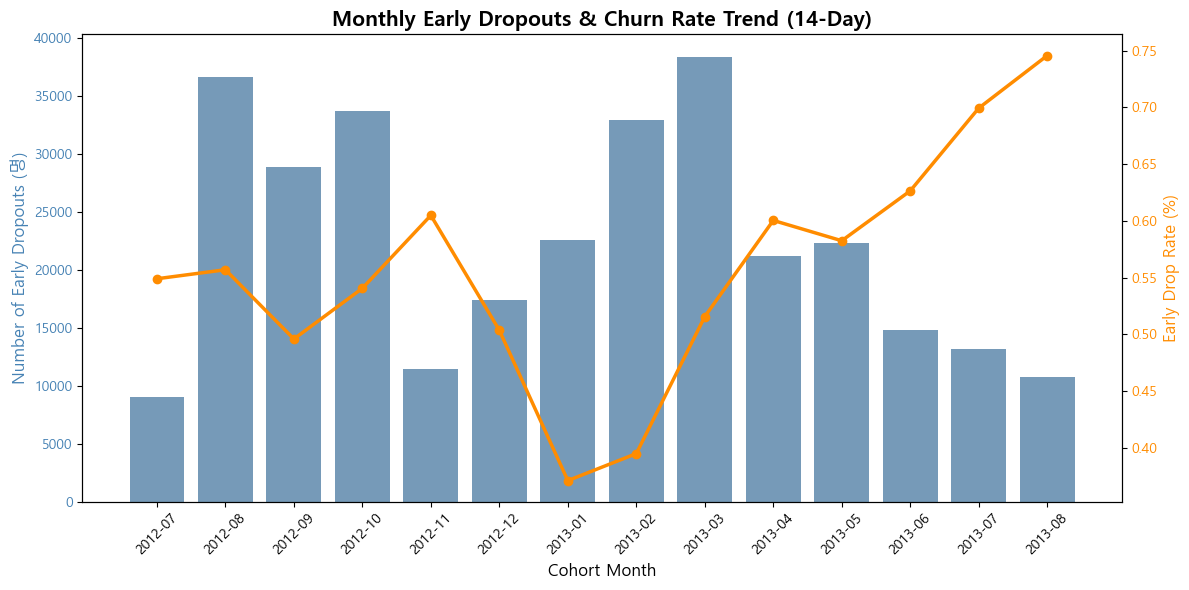

In [32]:
# (만약을 위해 안전하게 문자열 변환 한 번만 해줍니다)
df_cohort_period['cohort_month_str'] = df_cohort_period['cohort_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. 막대 그래프 (기존과 동일)
sns.barplot(data=df_cohort_period, x='cohort_month_str', y='drop_14_count', color='steelblue', ax=ax1, alpha=0.8)
ax1.set_xlabel('Cohort Month', fontsize=12)
ax1.set_ylabel('Number of Early Dropouts (명)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx() 

# 🌟 2. 여기가 핵심입니다! sns.lineplot 대신 ax2.plot() 사용
# x축 좌표를 막대그래프와 똑같이 0, 1, 2... 로 강제 지정해줍니다.
x_positions = range(len(df_cohort_period)) 
ax2.plot(x_positions, df_cohort_period['drop_2_rate'], color='darkorange', marker='o', linewidth=2.5)

ax2.set_ylabel('Early Drop Rate (%)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Monthly Early Dropouts & Churn Rate Trend (14-Day)', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

- 가입 월별 이탈률을 확인했을 때, 1,2월의 이탈률이 상대적으로 낮고 이후 점진적으로 초기 이탈률이 증가하는 것을 확인할 수 있다.

- 하지만, 강의의 강좌 시작월을 통해 구체적으로 분석해야지 초기 이탈을 보다 정확하게 정의할 수 있기 때문에, 추후 강좌 개설 이후 진입 월별 분석을 진행하였다.

In [33]:
course_korean_map = {

    # 🏛️ HarvardX 강좌

    'HarvardX/PH207x/2012_Fall': '건강 수치: 임상 및 공중 보건 연구의 정량적 방법 (12 가을, Harvard)',

    'HarvardX/CB22x/2013_Spring': '고대 그리스 영웅 (13 봄, Harvard)',

    'HarvardX/ER22x/2013_Spring': '정의란 무엇인가 (13 봄, Harvard )',

    'HarvardX/PH278x/2013_Spring': '인류 건강과 환경 변화 (13 봄, Harvard)',

    'HarvardX/CS50x/2012': '컴퓨터 과학 개론 I (CS50) (12년, Harvard)',

    

    # 🔬 MITx 강좌

    'MITx/6.002x/2012_Fall': '회로 및 전자공학 (12 가을, MIT)',

    'MITx/6.002x/2013_Spring': '회로 및 전자공학 (13 봄, MIT)',

    'MITx/6.00x/2012_Fall': '컴퓨터 과학 및 프로그래밍 개론 (12 가을, MIT)',

    'MITx/6.00x/2013_Spring': '컴퓨터 과학 및 프로그래밍 개론 (13 봄, MIT)',

    'MITx/3.091x/2012_Fall': '고체 화학 개론 (12 가을, MIT)',

    'MITx/3.091x/2013_Spring': '고체 화학 개론 (13 봄, MIT)',

    'MITx/7.00x/2013_Spring': '생물학 개론: 생명의 비밀 (13 봄, MIT)',

    'MITx/8.02x/2013_Spring': '전자기학 (13 봄, MIT)',

    'MITx/2.01x/2013_Spring': '구조 역학 기초 (13 봄, MIT)',

    'MITx/14.73x/2013_Spring': '글로벌 빈곤의 과제 (13 봄, MIT)',

    'MITx/8.MReV/2013_Summer': '역학 리뷰 (Mechanics ReView) (13 여름, MIT)'

}

df['course_name_kr'] = df['course_id'].map(course_korean_map)

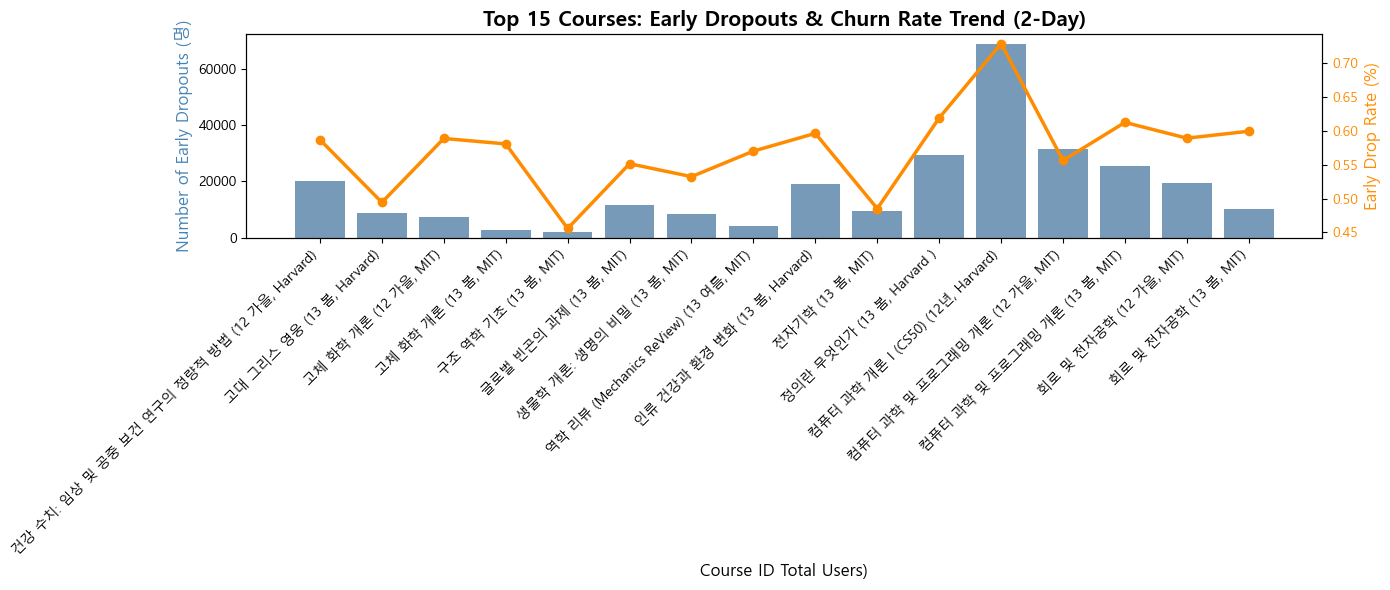

In [ ]:
# 1. 강의별 집계
df_cohort_course = df.groupby('course_name_kr').agg(
    total_users=('early_drop_2', 'count'),
    drop_2_count=('early_drop_2', 'sum'), 
    drop_2_rate=('early_drop_2', 'mean'), 
    drop_14_count=('early_drop_14', 'sum'),      
    drop_14_rate=('early_drop_14', 'mean')       
).reset_index()

top_courses = df_cohort_course.sort_values(by='total_users', ascending=False).copy()

top_courses = top_courses.sort_values(by = 'course_name_kr').reset_index(drop = True)

# 3. X축 에러 방지를 위해 강의 ID를 문자열로 변환
# top_courses['course_id_str'] = top_courses['course_id'].astype(str)

# ----------------- 그래프 그리기 -----------------
fig, ax1 = plt.subplots(figsize=(14, 6))

# 4. 막대 그래프 (이탈 유저 수)
sns.barplot(data=top_courses, x='course_name_kr', y='drop_2_count', color='steelblue', ax=ax1, alpha=0.8)
ax1.set_xlabel('Course ID Total Users)', fontsize=12)
ax1.set_ylabel('Number of Early Dropouts (명)', color='steelblue', fontsize=12)
ax1.set_xticks(range(len(top_courses))) # 경고 메시지 방지용
ax1.set_xticklabels(top_courses['course_name_kr'], rotation=45, ha='right')

# 5. 꺾은선 그래프 (이탈률)
ax2 = ax1.twinx() 
x_positions = range(len(top_courses))
ax2.plot(x_positions, top_courses['drop_14_rate'], color='darkorange', marker='o', linewidth=2.5)

ax2.set_ylabel('Early Drop Rate (%)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Top 15 Courses: Early Dropouts & Churn Rate Trend (2-Day)', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

In [20]:
df[(df['course_id'] == 'HarvardX/PH278x/2013_Spring') | (df['course_id'] == 'MITx/14.73x/2013_Spring')][['cohort_month']].value_counts()

cohort_month
2013-01         15786
2013-02         13752
2013-03          7935
2012-12          7080
2013-05          6267
2013-04          5591
2013-06          1510
2013-08          1377
2013-07           984
2013-09           324
Name: count, dtype: int64

In [21]:
course_start_df = df.groupby(['course_id'])['cohort_month'].min().sort_values().reset_index()
course_start_df

,course_id,cohort_month
0,HarvardX/CS50x/2012,2012-07
1,HarvardX/PH207x/2012_Fall,2012-07
2,MITx/3.091x/2012_Fall,2012-07
3,MITx/6.002x/2012_Fall,2012-07
4,MITx/6.00x/2012_Fall,2012-07
5,HarvardX/PH278x/2013_Spring,2012-12
6,HarvardX/ER22x/2013_Spring,2012-12
7,HarvardX/CB22x/2013_Spring,2012-12
8,MITx/6.00x/2013_Spring,2012-12
9,MITx/14.73x/2013_Spring,2012-12


In [22]:
df.columns

Index(['course_id', 'userid_DI', 'registered', 'viewed', 'explored',
       'certified', 'final_cc_cname_DI', 'LoE_DI', 'YoB', 'gender', 'grade',
       'start_time_DI', 'last_event_DI', 'nevents', 'ndays_act', 'nplay_video',
       'nchapters', 'nforum_posts', 'viewed_missing_flag', 'duration',
       'fast_completion_flag', 'start_year', 'age_raw', 'age_missing_original',
       'age_invalid', 'age_cleaned', 'age_final', 'age', 'age_group',
       'exam_flag', 'LoE_num', 'nchapters_p75', 'sufficient', 'early_drop',
       'early_drop_14', 'early_drop_2', 'cohort_month'],
      dtype='str')

In [23]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['cohort_month'] == '2012-07', 'course_id'])].groupby('cohort_month').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
cohort_month,,
2012-07,16261,0.556177
2012-08,64322,0.570116
2012-09,51621,0.560160
2012-10,51649,0.653488
2012-11,16854,0.679957
2012-12,11918,0.686860
2013-01,4905,0.511315
2013-02,5509,0.651116
2013-03,9504,0.775779


In [24]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['cohort_month'] == '2012-12', 'course_id'])].groupby('cohort_month').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
cohort_month,,
2012-12,21154,0.437128
2013-01,45407,0.423415
2013-02,42562,0.496523
2013-03,36030,0.650958
2013-04,18838,0.692643
2013-05,18321,0.725615
2013-06,8659,0.740617
2013-07,8784,0.812158
2013-08,11314,0.921248


In [25]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['cohort_month'] == '2013-01', 'course_id'])].groupby('cohort_month').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
cohort_month,,
2013-01,7943,0.104872
2013-02,17920,0.454855
2013-03,10233,0.665103
2013-04,4572,0.739064
2013-05,2678,0.760269
2013-06,652,0.707055
2013-07,58,0.637931
2013-08,1120,0.891071
2013-09,268,1.000000


In [26]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['cohort_month'] == '2013-02', 'course_id'])].groupby('cohort_month').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
cohort_month,,
2013-02,301,0.312292
2013-03,2282,0.351884
2013-04,2056,0.490272
2013-05,836,0.684211
2013-06,59,0.711864
2013-07,3,0.666667
2013-08,8,0.750000
2013-09,1,1.000000


In [27]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['cohort_month'] == '2013-04', 'course_id'])].groupby('cohort_month').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
cohort_month,,
2013-04,496,0.364919
2013-05,3312,0.364130
2013-06,2606,0.630468
2013-07,1415,0.745583
2013-08,848,0.919811
2013-09,186,1.000000


In [45]:
df_course = df.merge(course_start_df.rename(columns = {'cohort_month':'course_start_month'}), how = 'left', on = 'course_id')
df_course['enter_after_start'] = (df_course['cohort_month'] - df_course['course_start_month']).apply(lambda x: x.n) + 1
df_course['enter_after_start'].value_counts()

enter_after_start
2     133243
3     109078
4      94502
1      46155
5      39277
6      31080
9      21086
8      15414
7      13630
12      7645
10      7078
11      6571
13      5581
14      2949
15       704
Name: count, dtype: int64

In [48]:
df_enter_plot = df_course.groupby('enter_after_start').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
).reset_index()
df_enter_plot

,enter_after_start,user_count,drop_rate_14
0,1,46155,0.420301
1,2,133243,0.495763
2,3,109078,0.545536
3,4,94502,0.658314
4,5,39277,0.696744
5,6,31080,0.712001
6,7,13630,0.657667
7,8,15414,0.760348
8,9,21086,0.856682
9,10,7078,0.865781


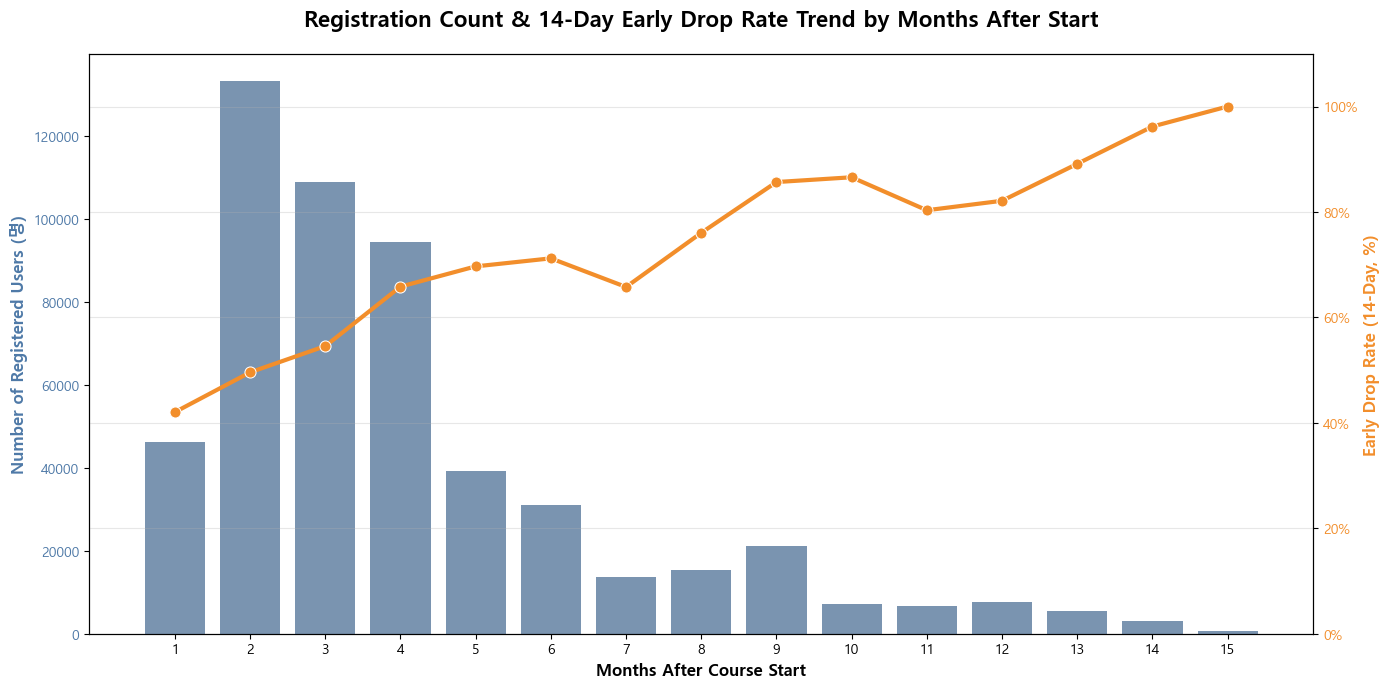

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# ------------------------------------------------------------------
# [단계 1] image_13.png의 데이터를 바탕으로 데이터프레임 직접 생성
# 실제 사용 시에는 회원님의 df_enter_plot 데이터프레임을 그대로 사용하세요.
# ------------------------------------------------------------------


# 시각화 시 가독성을 위해 rate를 100을 곱해 %로 만듭니다.
df_enter_plot['drop_rate_14_pct'] = df_enter_plot['drop_rate_14'] * 100

# ------------------------------------------------------------------
# [단계 2] 이중 축 콤보 차트 시각화 코드
# ------------------------------------------------------------------

# 한글 폰트 설정 (필요시 사용, 여기서는 기본 영문 폰트 사용)
# plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic') # Mac

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- 주 축 (ax1): 개강 후 주차별 가입 유저 수 (막대 그래프) ---
# 대시보드 기획안의 막대 색상과 유사한 색상 설정
bar_color = '#4e79a7' # Tableau 스타일 파란색

sns.barplot(
    data=df_enter_plot,
    x='enter_after_start',
    y='user_count',
    color=bar_color,
    alpha=0.8,
    ax=ax1
)

# 좌측 Y축 라벨 및 포맷 설정
ax1.set_ylabel('Number of Registered Users (명)', color=bar_color, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=bar_color)
ax1.set_xlabel('Months After Course Start', fontsize=12, fontweight='bold')


# --- 보조 축 (ax2): 초기 이탈률 (꺾은선 그래프) ---
ax2 = ax1.twinx()  # ax1과 x축을 공유하는 새로운 y축을 만듭니다.

# 대시보드 기획안의 꺾은선 색상과 유사한 오렌지색 설정
line_color = '#f28e2b' # Tableau 스타일 오렌지색

sns.lineplot(
    data=df_enter_plot,
    x=range(len(df_enter_plot)), # X축 위치를 강제로 막대 중앙으로 맞춥니다.
    y='drop_rate_14_pct',
    color=line_color,
    linewidth=3,
    marker='o',        # 데이터 포인트에 점 표시
    markersize=8,
    ax=ax2
)

# 우측 Y축 라벨 및 포맷 설정 (% 표시 추가)
ax2.set_ylabel('Early Drop Rate (14-Day, %)', color=line_color, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=line_color)
ax2.yaxis.set_major_formatter(PercentFormatter()) # Y축 값을 % 포맷으로 변경
ax2.set_ylim(0, 110)  # 비율이므로 0~100%+ 여유값 설정


# --- 전체 그래프 설정 ---
# 제목은 대시보드 기획안의 "Monthly Early Dropouts..." 부분을 참고하여 데이터에 맞게 수정
plt.title('Registration Count & 14-Day Early Drop Rate Trend by Months After Start', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, axis='y', alpha=0.3)  # Y축 그리드만 표시

# 그래프 저장 (선택 사항)
# plt.savefig('early_drop_trend_by_weeks.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### 2. 학력 및 나이 관련

In [57]:
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize, proportion_confint
from statsmodels.stats.power import NormalIndPower
from scipy.stats import chi2_contingency
from scipy.stats import pointbiserialr

ct = pd.crosstab(df['early_drop_14'], df['LoE_DI'])
display(ct)

LoE_DI,Bachelor's,Doctorate,Less than Secondary,Master's,Secondary,unknown
early_drop_14,,,,,,
0,67444,4751,4386,41030,51778,42988
1,115987,6908,6783,59524,87543,44871


In [58]:
chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

검정 통계량 및 p-value : 4212.0983, 0.0000


array([[ 72953.2512355 ,   4636.95861744,   4442.07829129,
         39991.82921499,  55410.0447328 ,  34942.83790799],
       [110477.7487645 ,   7022.04138256,   6726.92170871,
         60562.17078501,  83910.9552672 ,  52916.16209201]])

[[ 67444   4751   4386  41030  51778  42988]
 [115987   6908   6783  59524  87543  44871]]


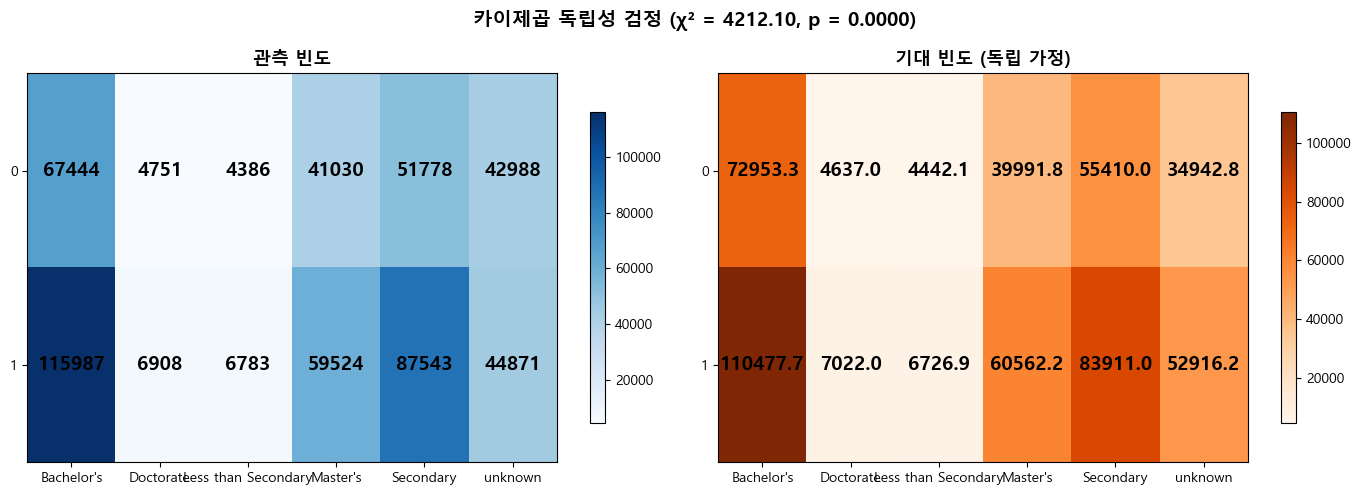

In [59]:
#### 무아 튜터님 자료 그대로 복붙(솔직하게 보고용 이쁘게 만든 자료. 필요없긴함)
# ── 시각화: 교차표 히트맵 ──
# 관측 빈도 히트맵
ct_raw = ct
ct_obs = ct_raw.values
print(ct_obs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(ct_obs, cmap='Blues', aspect='auto')
axes[0].set_title('관측 빈도', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(ct_raw.columns)))
axes[0].set_xticklabels(ct_raw.columns)
axes[0].set_yticks(range(len(ct_raw.index)))
axes[0].set_yticklabels(ct_raw.index)
for i in range(ct_obs.shape[0]):
    for j in range(ct_obs.shape[1]):
        axes[0].text(j, i, f'{ct_obs[i, j]}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# 기대 빈도 히트맵
im2 = axes[1].imshow(expected, cmap='Oranges', aspect='auto')
axes[1].set_title('기대 빈도 (독립 가정)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(ct.columns)))
axes[1].set_xticklabels(ct_raw.columns)
axes[1].set_yticks(range(len(ct.index)))
axes[1].set_yticklabels(ct.index)
for i in range(expected.shape[0]):
    for j in range(expected.shape[1]):
        axes[1].text(j, i, f'{expected[i, j]:.1f}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

fig.suptitle(f"카이제곱 독립성 검정 (χ² = {chi2_stat:.2f}, p = {p_val:.4f})",
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 효과크기 무의미
from scipy.stats.contingency import association

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

검정의 효과크기 : 0.0888


In [65]:
df_tmp = df[df['gender'] != 'o']

ct = pd.crosstab(df_tmp['early_drop_14'], df_tmp['gender'])
display(ct)

gender,f,m,unknown
early_drop_14,,,
0,45758,128644,37975
1,75055,211665,34888


In [66]:
chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

검정 통계량 및 p-value : 5369.4708, 0.0000


array([[ 48049.85627124, 135348.00508067,  28979.13864809],
       [ 72763.14372876, 204960.99491933,  43883.86135191]])

[[ 45758 128644  37975]
 [ 75055 211665  34888]]


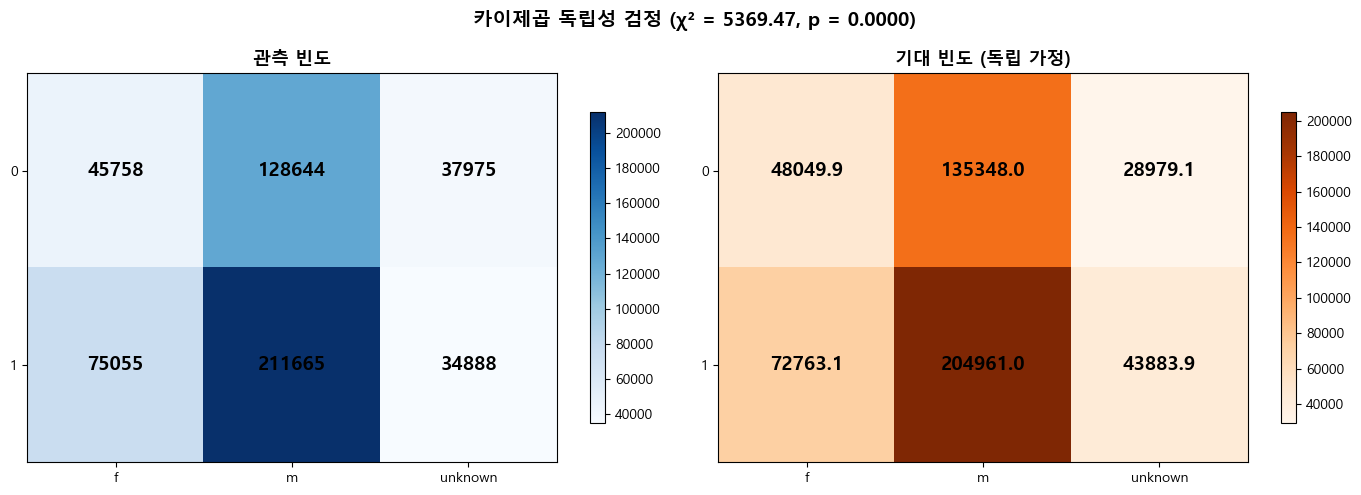

In [67]:
#### 무아 튜터님 자료 그대로 복붙(솔직하게 보고용 이쁘게 만든 자료. 필요없긴함)
# ── 시각화: 교차표 히트맵 ──
# 관측 빈도 히트맵
ct_raw = ct
ct_obs = ct_raw.values
print(ct_obs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(ct_obs, cmap='Blues', aspect='auto')
axes[0].set_title('관측 빈도', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(ct_raw.columns)))
axes[0].set_xticklabels(ct_raw.columns)
axes[0].set_yticks(range(len(ct_raw.index)))
axes[0].set_yticklabels(ct_raw.index)
for i in range(ct_obs.shape[0]):
    for j in range(ct_obs.shape[1]):
        axes[0].text(j, i, f'{ct_obs[i, j]}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# 기대 빈도 히트맵
im2 = axes[1].imshow(expected, cmap='Oranges', aspect='auto')
axes[1].set_title('기대 빈도 (독립 가정)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(ct.columns)))
axes[1].set_xticklabels(ct_raw.columns)
axes[1].set_yticks(range(len(ct.index)))
axes[1].set_yticklabels(ct.index)
for i in range(expected.shape[0]):
    for j in range(expected.shape[1]):
        axes[1].text(j, i, f'{expected[i, j]:.1f}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

fig.suptitle(f"카이제곱 독립성 검정 (χ² = {chi2_stat:.2f}, p = {p_val:.4f})",
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [68]:
# 효과크기 무의미
from scipy.stats.contingency import association

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

검정의 효과크기 : 0.1003


In [69]:
ct = pd.crosstab(df['early_drop_14'], df['age_group'])
display(ct)

age_group,20s,30s,40s,50s,60_plus,under_20,unknown
early_drop_14,,,,,,,
0,101558,32600,9398,4220,2064,21389,41148
1,168024,53671,16063,6599,2645,34708,39906


In [70]:
chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

검정 통계량 및 p-value : 4913.1878, 0.0000


array([[107216.79200664,  34311.26656529,  10126.22037555,
          4302.87805833,   1872.83970576,  22310.61562417,
         32236.38766426],
       [162365.20799336,  51959.73343471,  15334.77962445,
          6516.12194167,   2836.16029424,  33786.38437583,
         48817.61233574]])

[[101558  32600   9398   4220   2064  21389  41148]
 [168024  53671  16063   6599   2645  34708  39906]]


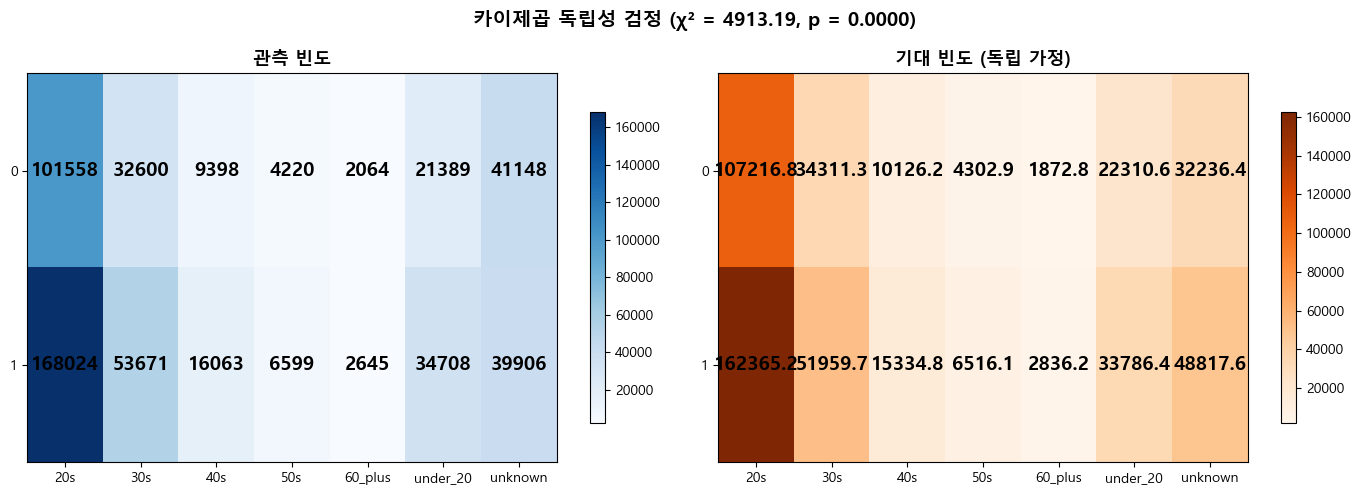

In [71]:
#### 무아 튜터님 자료 그대로 복붙(솔직하게 보고용 이쁘게 만든 자료. 필요없긴함)
# ── 시각화: 교차표 히트맵 ──
# 관측 빈도 히트맵
ct_raw = ct
ct_obs = ct_raw.values
print(ct_obs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(ct_obs, cmap='Blues', aspect='auto')
axes[0].set_title('관측 빈도', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(ct_raw.columns)))
axes[0].set_xticklabels(ct_raw.columns)
axes[0].set_yticks(range(len(ct_raw.index)))
axes[0].set_yticklabels(ct_raw.index)
for i in range(ct_obs.shape[0]):
    for j in range(ct_obs.shape[1]):
        axes[0].text(j, i, f'{ct_obs[i, j]}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# 기대 빈도 히트맵
im2 = axes[1].imshow(expected, cmap='Oranges', aspect='auto')
axes[1].set_title('기대 빈도 (독립 가정)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(ct.columns)))
axes[1].set_xticklabels(ct_raw.columns)
axes[1].set_yticks(range(len(ct.index)))
axes[1].set_yticklabels(ct.index)
for i in range(expected.shape[0]):
    for j in range(expected.shape[1]):
        axes[1].text(j, i, f'{expected[i, j]:.1f}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

fig.suptitle(f"카이제곱 독립성 검정 (χ² = {chi2_stat:.2f}, p = {p_val:.4f})",
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [72]:
# 효과크기 무의미
from scipy.stats.contingency import association

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

검정의 효과크기 : 0.0959


In [74]:
language_map = {
    # 🇺🇸 영어권 (English)
    'United States': 'English', 'Australia': 'English', 'Canada': 'English', 
    'United Kingdom': 'English', 'India': 'English', 'Nigeria': 'English', 
    'Philippines': 'English', 'Pakistan': 'English', 

    # 🌐 비영어권 (Non-English)
    'France': 'Non-English', 'Russian Federation': 'Non-English', 'Mexico': 'Non-English', 
    'Japan': 'Non-English', 'Colombia': 'Non-English', 'Germany': 'Non-English', 
    'Indonesia': 'Non-English', 'Bangladesh': 'Non-English', 'China': 'Non-English', 
    'Ukraine': 'Non-English', 'Spain': 'Non-English', 'Brazil': 'Non-English', 
    'Poland': 'Non-English', 'Egypt': 'Non-English', 'Greece': 'Non-English', 
    'Portugal': 'Non-English', 'Morocco': 'Non-English',
    'Other North & Central Amer., Caribbean': 'Non-English', 'Other South Asia': 'Non-English', 
    'Other Europe': 'Non-English', 'Other Africa': 'Non-English', 
    'Other Middle East/Central Asia': 'Non-English', 'Other East Asia': 'Non-English', 
    'Other South America': 'Non-English', 'Other Oceania': 'Non-English',

    # ❓ 알 수 없음
    'Unknown/Other': 'Unknown'
}

In [ ]:
# 기각.
df['language_group'] = df['final_cc_cname_DI'].map(language_map)
df.groupby('language_group')['early_drop'].mean()

language_group
English        0.577296
Non-English    0.543623
Unknown        0.981789
Name: early_drop, dtype: float64

In [78]:
df.groupby('final_cc_cname_DI')['early_drop'].mean()

final_cc_cname_DI
Australia                                 0.589491
Bangladesh                                0.589538
Brazil                                    0.565089
Canada                                    0.575106
China                                     0.675000
Colombia                                  0.475444
Egypt                                     0.618129
France                                    0.550012
Germany                                   0.506576
Greece                                    0.432124
India                                     0.547897
Indonesia                                 0.608448
Japan                                     0.637817
Mexico                                    0.493530
Morocco                                   0.703525
Nigeria                                   0.571113
Other Africa                              0.591300
Other East Asia                           0.631065
Other Europe                              0.504967
Other Middle 

In [80]:
economy_map = {
    # 🏙️ 선진국 (Developed)
    'United States': 'Developed', 'France': 'Developed', 'Australia': 'Developed', 
    'Canada': 'Developed', 'Japan': 'Developed', 'Germany': 'Developed', 
    'United Kingdom': 'Developed', 'Spain': 'Developed', 'Greece': 'Developed', 
    'Portugal': 'Developed', 'Poland': 'Developed', 'Other Europe': 'Developed', 
    'Other Oceania': 'Developed',

    # 🏭 개발도상국 (Developing)
    'Russian Federation': 'Developing', 'India': 'Developing', 'Mexico': 'Developing', 
    'Colombia': 'Developing', 'Indonesia': 'Developing', 'China': 'Developing', 
    'Ukraine': 'Developing', 'Brazil': 'Developing', 'Egypt': 'Developing', 
    'Philippines': 'Developing', 'Morocco': 'Developing', 'Bangladesh': 'Developing', 
    'Pakistan': 'Developing', 'Nigeria': 'Developing', 
    'Other South America': 'Developing', 'Other North & Central Amer., Caribbean': 'Developing', 
    'Other East Asia': 'Developing', 'Other Middle East/Central Asia': 'Developing',
    'Other South Asia': 'Developing', 'Other Africa': 'Developing',

    # ❓ 알 수 없음
    'Unknown/Other': 'Unknown'
}

In [81]:
# 기각.
df['economy_group'] = df['final_cc_cname_DI'].map(economy_map)
df.groupby('economy_group')['early_drop'].mean()

economy_group
Developed     0.562714
Developing    0.564987
Unknown       0.981789
Name: early_drop, dtype: float64

In [82]:
df.groupby('economy_group')['early_drop'].mean()

economy_group
Developed     0.562714
Developing    0.564987
Unknown       0.981789
Name: early_drop, dtype: float64

In [83]:
continent_map = {
    # 🌎 북미 / 중미 (North America)
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    'Other North & Central Amer., Caribbean': 'North America',

    # 🌎 남미 (South America)
    'Colombia': 'South America',
    'Brazil': 'South America',
    'Other South America': 'South America',

    # 🌍 유럽 (Europe)
    'France': 'Europe',
    'Russian Federation': 'Europe', 
    'Germany': 'Europe',
    'United Kingdom': 'Europe',
    'Ukraine': 'Europe',
    'Spain': 'Europe',
    'Poland': 'Europe',
    'Greece': 'Europe',
    'Portugal': 'Europe',
    'Other Europe': 'Europe',

    # 🌏 아시아 (Asia) - 중동 포함
    'India': 'Asia',
    'Japan': 'Asia',
    'Indonesia': 'Asia',
    'Bangladesh': 'Asia',
    'China': 'Asia',
    'Pakistan': 'Asia',
    'Philippines': 'Asia',
    'Other South Asia': 'Asia',
    'Other East Asia': 'Asia',
    'Other Middle East/Central Asia': 'Asia',

    # 🌍 아프리카 (Africa)
    'Nigeria': 'Africa',
    'Egypt': 'Africa',
    'Morocco': 'Africa',
    'Other Africa': 'Africa',

    # 🌊 오세아니아 (Oceania)
    'Australia': 'Oceania',
    'Other Oceania': 'Oceania',

    # ❓ 알 수 없음
    'Unknown/Other': 'Unknown'
}

In [85]:
df['continent'] = df['final_cc_cname_DI'].map(continent_map)
df.groupby('continent')['early_drop'].mean()

continent
Africa           0.603802
Asia             0.571653
Europe           0.496222
North America    0.589746
Oceania          0.588624
South America    0.539524
Unknown          0.981789
Name: early_drop, dtype: float64

In [86]:
ct = pd.crosstab(df['early_drop_14'], df['continent'])
display(ct)

continent,Africa,Asia,Europe,North America,Oceania,South America,Unknown
early_drop_14,,,,,,,
0,15466,59036,49475,71776,2365,13363,896
1,23570,78787,48733,103179,3384,15657,48306


In [87]:
chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

검정 통계량 및 p-value : 35331.8506, 0.0000


array([[ 15525.20083971,  54814.26773572,  39058.78993919,
         69582.21930812,   2286.46325514,  11541.68788729,
         19568.37103483],
       [ 23510.79916029,  83008.73226428,  59149.21006081,
        105372.78069188,   3462.53674486,  17478.31211271,
         29633.62896517]])

[[ 15466  59036  49475  71776   2365  13363    896]
 [ 23570  78787  48733 103179   3384  15657  48306]]


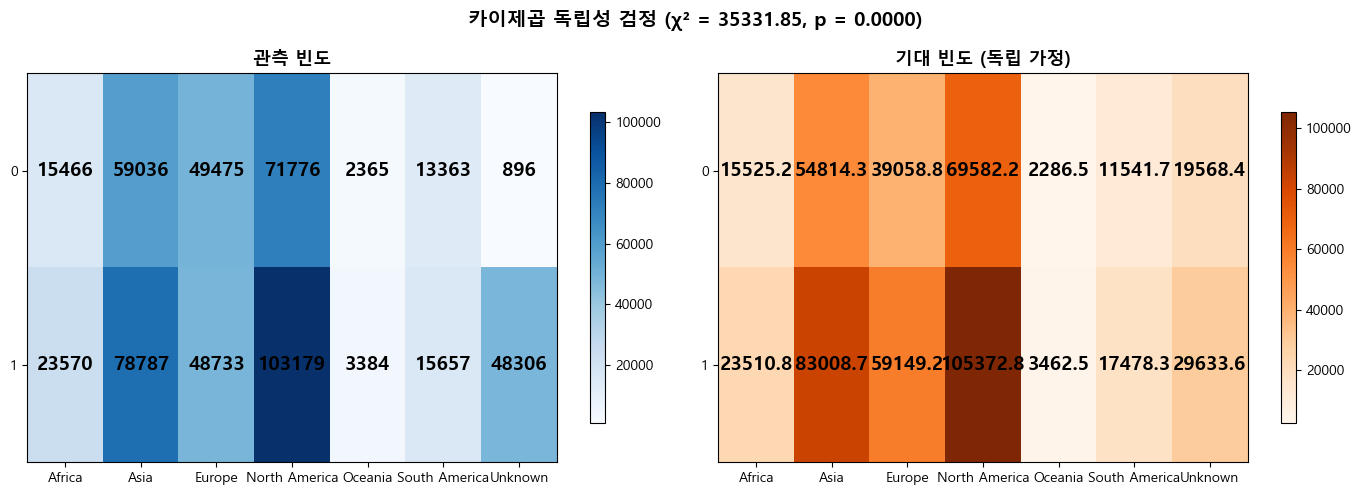

In [88]:
#### 무아 튜터님 자료 그대로 복붙(솔직하게 보고용 이쁘게 만든 자료. 필요없긴함)
# ── 시각화: 교차표 히트맵 ──
# 관측 빈도 히트맵
ct_raw = ct
ct_obs = ct_raw.values
print(ct_obs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(ct_obs, cmap='Blues', aspect='auto')
axes[0].set_title('관측 빈도', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(ct_raw.columns)))
axes[0].set_xticklabels(ct_raw.columns)
axes[0].set_yticks(range(len(ct_raw.index)))
axes[0].set_yticklabels(ct_raw.index)
for i in range(ct_obs.shape[0]):
    for j in range(ct_obs.shape[1]):
        axes[0].text(j, i, f'{ct_obs[i, j]}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# 기대 빈도 히트맵
im2 = axes[1].imshow(expected, cmap='Oranges', aspect='auto')
axes[1].set_title('기대 빈도 (독립 가정)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(ct.columns)))
axes[1].set_xticklabels(ct_raw.columns)
axes[1].set_yticks(range(len(ct.index)))
axes[1].set_yticklabels(ct.index)
for i in range(expected.shape[0]):
    for j in range(expected.shape[1]):
        axes[1].text(j, i, f'{expected[i, j]:.1f}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

fig.suptitle(f"카이제곱 독립성 검정 (χ² = {chi2_stat:.2f}, p = {p_val:.4f})",
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [89]:
# 효과크기 무의미
from scipy.stats.contingency import association

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

검정의 효과크기 : 0.2572


In [90]:
df_tmp = df[df['continent'] != 'Unknown']

ct = pd.crosstab(df_tmp['early_drop_14'], df_tmp['continent'])
display(ct)

continent,Africa,Asia,Europe,North America,Oceania,South America
early_drop_14,,,,,,
0,15466,59036,49475,71776,2365,13363
1,23570,78787,48733,103179,3384,15657


In [91]:
chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

검정 통계량 및 p-value : 2675.0158, 0.0000


array([[17028.72436988, 60122.70414055, 42841.40185771, 76320.84414727,
         2507.89364695, 12659.43183764],
       [22007.27563012, 77700.29585945, 55366.59814229, 98634.15585273,
         3241.10635305, 16360.56816236]])

In [92]:
chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

검정 통계량 및 p-value : 2675.0158, 0.0000


array([[17028.72436988, 60122.70414055, 42841.40185771, 76320.84414727,
         2507.89364695, 12659.43183764],
       [22007.27563012, 77700.29585945, 55366.59814229, 98634.15585273,
         3241.10635305, 16360.56816236]])

[[ 15466  59036  49475  71776   2365  13363]
 [ 23570  78787  48733 103179   3384  15657]]


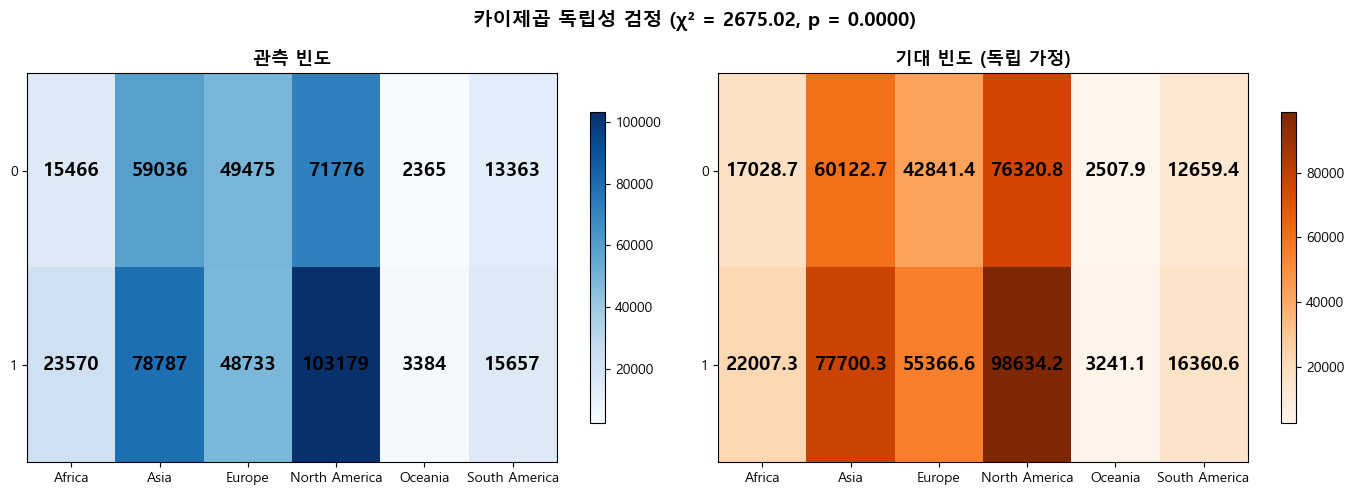

In [93]:
#### 무아 튜터님 자료 그대로 복붙(솔직하게 보고용 이쁘게 만든 자료. 필요없긴함)
# ── 시각화: 교차표 히트맵 ──
# 관측 빈도 히트맵
ct_raw = ct
ct_obs = ct_raw.values
print(ct_obs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(ct_obs, cmap='Blues', aspect='auto')
axes[0].set_title('관측 빈도', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(ct_raw.columns)))
axes[0].set_xticklabels(ct_raw.columns)
axes[0].set_yticks(range(len(ct_raw.index)))
axes[0].set_yticklabels(ct_raw.index)
for i in range(ct_obs.shape[0]):
    for j in range(ct_obs.shape[1]):
        axes[0].text(j, i, f'{ct_obs[i, j]}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# 기대 빈도 히트맵
im2 = axes[1].imshow(expected, cmap='Oranges', aspect='auto')
axes[1].set_title('기대 빈도 (독립 가정)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(ct.columns)))
axes[1].set_xticklabels(ct_raw.columns)
axes[1].set_yticks(range(len(ct.index)))
axes[1].set_yticklabels(ct.index)
for i in range(expected.shape[0]):
    for j in range(expected.shape[1]):
        axes[1].text(j, i, f'{expected[i, j]:.1f}', ha='center', va='center',
                    fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

fig.suptitle(f"카이제곱 독립성 검정 (χ² = {chi2_stat:.2f}, p = {p_val:.4f})",
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [94]:
# 효과크기 무의미
from scipy.stats.contingency import association

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

검정의 효과크기 : 0.0743


In [96]:
df[df['final_cc_cname_DI'] == 'Unknown/Other']['course_id'].value_counts()

course_id
HarvardX/CS50x/2012            26521
HarvardX/ER22x/2013_Spring      6135
HarvardX/PH278x/2013_Spring     4555
MITx/6.00x/2012_Fall            2413
HarvardX/PH207x/2012_Fall       1964
MITx/6.002x/2012_Fall           1468
MITx/6.00x/2013_Spring          1425
MITx/14.73x/2013_Spring         1331
MITx/7.00x/2013_Spring           862
MITx/8.02x/2013_Spring           833
MITx/6.002x/2013_Spring          800
MITx/3.091x/2012_Fall            387
MITx/8.MReV/2013_Summer          245
MITx/3.091x/2013_Spring          136
MITx/2.01x/2013_Spring            72
HarvardX/CB22x/2013_Spring        55
Name: count, dtype: int64

In [97]:
df['course_id'].value_counts()

course_id
HarvardX/CS50x/2012            100467
MITx/6.00x/2012_Fall            66124
HarvardX/ER22x/2013_Spring      54636
MITx/6.00x/2013_Spring          50652
HarvardX/PH207x/2012_Fall       41110
MITx/6.002x/2012_Fall           38935
HarvardX/PH278x/2013_Spring     35458
MITx/8.02x/2013_Spring          25886
MITx/14.73x/2013_Spring         25148
HarvardX/CB22x/2013_Spring      22915
MITx/7.00x/2013_Spring          19558
MITx/6.002x/2013_Spring         19444
MITx/3.091x/2012_Fall           13926
MITx/8.MReV/2013_Summer          8863
MITx/2.01x/2013_Spring           5546
MITx/3.091x/2013_Spring          5325
Name: count, dtype: int64

In [98]:
df['course_id'].unique()

<StringArray>
[  'HarvardX/PH207x/2012_Fall',  'HarvardX/CB22x/2013_Spring',
  'HarvardX/ER22x/2013_Spring', 'HarvardX/PH278x/2013_Spring',
         'HarvardX/CS50x/2012',       'MITx/6.002x/2012_Fall',
     'MITx/6.002x/2013_Spring',      'MITx/2.01x/2013_Spring',
       'MITx/3.091x/2012_Fall',        'MITx/6.00x/2012_Fall',
      'MITx/7.00x/2013_Spring',      'MITx/8.02x/2013_Spring',
     'MITx/3.091x/2013_Spring',     'MITx/14.73x/2013_Spring',
      'MITx/6.00x/2013_Spring',     'MITx/8.MReV/2013_Summer']
Length: 16, dtype: str